In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load data
df = pd.read_excel('Book1.xlsx', sheet_name='Master_combined')

print("✅ Data loaded successfully!")
print(f"📊 Total rows: {len(df)}")
print(f"📊 Total columns: {len(df.columns)}")
print(f"📊 Years: {df['Year'].min()} - {df['Year'].max()}")
print(f"📊 Cities: {df['City'].unique().tolist()}")

✅ Data loaded successfully!
📊 Total rows: 661
📊 Total columns: 13
📊 Years: 2015 - 2024
📊 Cities: ['Cologne', 'Leipzig', 'Stuttgart']


In [ ]:
print("=" * 60)
print("📊 DEFINING FEATURES AND TARGETS")
print("=" * 60)

# Define features (climate variables)
feature_columns = ['temperature', 'rainfall', 'SPI']

# Define targets (groundwater parameters to predict)
target_columns = ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

print(f"\n📌 Features: {feature_columns}")
print(f"📌 Targets: {target_columns}")

# Check for missing values in features
print("\n--- Missing values in features ---")
for col in feature_columns:
    missing = df[col].isnull().sum()
    print(f"  {col}: {missing} missing ({missing/len(df)*100:.1f}%)")

print("\n--- Missing values in targets ---")
for col in target_columns:
    missing = df[col].isnull().sum()
    print(f"  {col}: {missing} missing ({missing/len(df)*100:.1f}%)")

📊 DEFINING FEATURES AND TARGETS

📌 Features: ['temperature', 'rainfall', 'SPI']
📌 Targets: ['EC', 'nitrate', 'chloride', 'sulfate', 'pH']

--- Missing values in features ---
  temperature: 0 missing (0.0%)
  rainfall: 0 missing (0.0%)
  SPI: 0 missing (0.0%)

--- Missing values in targets ---
  EC: 6 missing (0.9%)
  nitrate: 9 missing (1.4%)
  chloride: 59 missing (8.9%)
  sulfate: 59 missing (8.9%)
  pH: 4 missing (0.6%)


In [ ]:
print("=" * 60)
print("📊 TEMPORAL HOLDOUT SPLIT")
print("=" * 60)

# Define train and test years
train_years = [2015, 2016, 2017, 2018, 2019, 2020, 2021]
test_years = [2022, 2023, 2024]

# Create train and test sets
train_df = df[df['Year'].isin(train_years)].copy()
test_df = df[df['Year'].isin(test_years)].copy()

# Remove rows with missing target values (for each target separately later)
print(f"\n📌 Training years: {train_years}")
print(f"   Training rows: {len(train_df)}")
print(f"\n📌 Testing years: {test_years}")
print(f"   Testing rows: {len(test_df)}")

print(f"\n📌 Split ratio: {len(train_df)/len(df)*100:.1f}% / {len(test_df)/len(df)*100:.1f}%")

📊 TEMPORAL HOLDOUT SPLIT

📌 Training years: [2015, 2016, 2017, 2018, 2019, 2020, 2021]
   Training rows: 484

📌 Testing years: [2022, 2023, 2024]
   Testing rows: 177

📌 Split ratio: 73.2% / 26.8%


In [ ]:
print("=" * 60)
print("📊 EVALUATION FUNCTION")
print("=" * 60)

def evaluate_model(y_true, y_pred, model_name, target_name):
    """Calculate evaluation metrics for a model"""
    # Remove any NaN values
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true_clean = np.array(y_true)[mask]
    y_pred_clean = np.array(y_pred)[mask]

    if len(y_true_clean) == 0:
        return {
            'model': model_name,
            'target': target_name,
            'MAE': np.nan,
            'RMSE': np.nan,
            'R2': np.nan,
            'n_samples': 0
        }

    mae = mean_absolute_error(y_true_clean, y_pred_clean)
    rmse = np.sqrt(mean_squared_error(y_true_clean, y_pred_clean))
    r2 = r2_score(y_true_clean, y_pred_clean)

    return {
        'model': model_name,
        'target': target_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'n_samples': len(y_true_clean)
    }

print("✅ Evaluation function created!")

📊 EVALUATION FUNCTION
✅ Evaluation function created!


In [ ]:
print("=" * 60)
print("📊 BASELINE 1: MEAN PREDICTION")
print("=" * 60)

mean_results = []

for target in target_columns:
    # Get training data for this target
    train_target = train_df[target].dropna()

    # Calculate mean of training data
    mean_value = train_target.mean()

    # Get test data for this target
    test_target = test_df[target].dropna()

    # Predict mean for all test points
    y_pred = np.full(len(test_target), mean_value)
    y_true = test_target.values

    # Evaluate
    result = evaluate_model(y_true, y_pred, 'Mean', target)
    mean_results.append(result)

    print(f"\n📌 {target.upper()}:")
    print(f"   Training mean: {mean_value:.2f}")
    print(f"   Test samples: {len(test_target)}")
    print(f"   MAE: {result['MAE']:.2f}")
    print(f"   RMSE: {result['RMSE']:.2f}")
    print(f"   R²: {result['R2']:.3f}")

# Convert to DataFrame
mean_results_df = pd.DataFrame(mean_results)
mean_results_df.to_excel('baseline_mean_results.xlsx', index=False)
print("\n✅ Mean prediction results saved to: baseline_mean_results.xlsx")

📊 BASELINE 1: MEAN PREDICTION

📌 EC:
   Training mean: 1092.62
   Test samples: 176
   MAE: 346.12
   RMSE: 445.60
   R²: -0.060

📌 NITRATE:
   Training mean: 12.27
   Test samples: 174
   MAE: 12.40
   RMSE: 16.85
   R²: -0.016

📌 CHLORIDE:
   Training mean: 74.67
   Test samples: 156
   MAE: 53.53
   RMSE: 75.09
   R²: -0.040

📌 SULFATE:
   Training mean: 256.76
   Test samples: 156
   MAE: 171.12
   RMSE: 205.03
   R²: -0.167

📌 PH:
   Training mean: 6.84
   Test samples: 177
   MAE: 0.43
   RMSE: 0.77
   R²: -0.028

✅ Mean prediction results saved to: baseline_mean_results.xlsx


In [ ]:
print("=" * 60)
print("📊 BASELINE 2: NAIVE PREDICTION (Last Year's Value)")
print("=" * 60)

naive_results = []

# For each station, use last available year's value as prediction
for target in target_columns:
    predictions = []
    actuals = []
    station_years = []

    for station in test_df['Station_id'].unique():
        # Get all data for this station
        station_data = df[df['Station_id'] == station].sort_values('Year')

        if len(station_data) < 2:
            continue

        # Last year's value (training data)
        train_station = station_data[station_data['Year'].isin(train_years)]
        test_station = station_data[station_data['Year'].isin(test_years)]

        if len(train_station) == 0 or len(test_station) == 0:
            continue

        # Get last available training year value
        last_train_value = train_station[target].dropna()
        if len(last_train_value) == 0:
            continue

        last_value = last_train_value.iloc[-1]

        # Predict this value for all test years
        test_values = test_station[target].dropna()
        for year in test_station['Year']:
            pred = last_value
            actual = test_station[test_station['Year'] == year][target].values

            if len(actual) > 0 and not pd.isna(actual[0]):
                predictions.append(pred)
                actuals.append(actual[0])
                station_years.append(f"{station}_{year}")

    if len(actuals) > 0:
        result = evaluate_model(actuals, predictions, 'Naive', target)
        naive_results.append(result)

        print(f"\n📌 {target.upper()}:")
        print(f"   Test samples: {len(actuals)}")
        print(f"   MAE: {result['MAE']:.2f}")
        print(f"   RMSE: {result['RMSE']:.2f}")
        print(f"   R²: {result['R2']:.3f}")
    else:
        print(f"\n📌 {target.upper()}: Insufficient data for naive prediction")

# Convert to DataFrame
naive_results_df = pd.DataFrame(naive_results)
naive_results_df.to_excel('baseline_naive_results.xlsx', index=False)
print("\n✅ Naive prediction results saved to: baseline_naive_results.xlsx")

📊 BASELINE 2: NAIVE PREDICTION (Last Year's Value)

📌 EC:
   Test samples: 65
   MAE: 100.07
   RMSE: 202.68
   R²: 0.593

📌 NITRATE:
   Test samples: 65
   MAE: 0.64
   RMSE: 2.26
   R²: 0.876

📌 CHLORIDE:
   Test samples: 65
   MAE: 5.72
   RMSE: 16.29
   R²: 0.780

📌 SULFATE:
   Test samples: 65
   MAE: 15.16
   RMSE: 49.06
   R²: 0.809

📌 PH:
   Test samples: 65
   MAE: 0.47
   RMSE: 0.96
   R²: -0.005

✅ Naive prediction results saved to: baseline_naive_results.xlsx


In [ ]:
print("=" * 60)
print("📊 BASELINE 3: LINEAR REGRESSION")
print("=" * 60)

lr_results = []

# Prepare features
X_train = train_df[feature_columns].copy()
X_test = test_df[feature_columns].copy()

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

for target in target_columns:
    # Get training data
    y_train = train_df[target].copy()

    # Remove rows with missing target
    train_mask = ~y_train.isna()
    X_train_clean = X_train_scaled[train_mask]
    y_train_clean = y_train[train_mask]

    if len(X_train_clean) == 0:
        print(f"\n📌 {target.upper()}: No training data")
        continue

    # Train model
    model = LinearRegression()
    model.fit(X_train_clean, y_train_clean)

    # Get test data
    y_test = test_df[target].copy()
    test_mask = ~y_test.isna()
    X_test_clean = X_test_scaled[test_mask]
    y_test_clean = y_test[test_mask]

    if len(X_test_clean) == 0:
        print(f"\n📌 {target.upper()}: No test data")
        continue

    # Predict
    y_pred = model.predict(X_test_clean)

    # Evaluate
    result = evaluate_model(y_test_clean, y_pred, 'Linear Regression', target)
    lr_results.append(result)

    print(f"\n📌 {target.upper()}:")
    print(f"   Training samples: {len(y_train_clean)}")
    print(f"   Test samples: {len(y_test_clean)}")
    print(f"   MAE: {result['MAE']:.2f}")
    print(f"   RMSE: {result['RMSE']:.2f}")
    print(f"   R²: {result['R2']:.3f}")

    # Show feature coefficients
    print(f"   Coefficients:")
    for i, feat in enumerate(feature_columns):
        print(f"      {feat}: {model.coef_[i]:.3f}")

# Convert to DataFrame
lr_results_df = pd.DataFrame(lr_results)
lr_results_df.to_excel('baseline_linear_results.xlsx', index=False)
print("\n✅ Linear Regression results saved to: baseline_linear_results.xlsx")

📊 BASELINE 3: LINEAR REGRESSION

📌 EC:
   Training samples: 479
   Test samples: 176
   MAE: 343.87
   RMSE: 472.42
   R²: -0.192
   Coefficients:
      temperature: -120.072
      rainfall: -110.105
      SPI: -28.245

📌 NITRATE:
   Training samples: 478
   Test samples: 174
   MAE: 10.79
   RMSE: 16.95
   R²: -0.028
   Coefficients:
      temperature: -2.444
      rainfall: -4.900
      SPI: 0.954

📌 CHLORIDE:
   Training samples: 446
   Test samples: 156
   MAE: 65.08
   RMSE: 89.79
   R²: -0.487
   Coefficients:
      temperature: -25.350
      rainfall: -17.364
      SPI: -9.159

📌 SULFATE:
   Training samples: 446
   Test samples: 156
   MAE: 104.95
   RMSE: 152.16
   R²: 0.357
   Coefficients:
      temperature: -29.938
      rainfall: -133.698
      SPI: 52.243

📌 PH:
   Training samples: 480
   Test samples: 177
   MAE: 0.55
   RMSE: 0.80
   R²: -0.124
   Coefficients:
      temperature: -0.111
      rainfall: -0.055
      SPI: -0.066

✅ Linear Regression results saved to: bas

In [ ]:
print("=" * 60)
print("📊 BASELINE 4: RIDGE REGRESSION")
print("=" * 60)

ridge_results = []

# Ridge uses same scaled features as Linear Regression
for target in target_columns:
    # Get training data
    y_train = train_df[target].copy()

    # Remove rows with missing target
    train_mask = ~y_train.isna()
    X_train_clean = X_train_scaled[train_mask]
    y_train_clean = y_train[train_mask]

    if len(X_train_clean) == 0:
        print(f"\n📌 {target.upper()}: No training data")
        continue

    # Train Ridge model (alpha=1.0 is default)
    model = Ridge(alpha=1.0)
    model.fit(X_train_clean, y_train_clean)

    # Get test data
    y_test = test_df[target].copy()
    test_mask = ~y_test.isna()
    X_test_clean = X_test_scaled[test_mask]
    y_test_clean = y_test[test_mask]

    if len(X_test_clean) == 0:
        print(f"\n📌 {target.upper()}: No test data")
        continue

    # Predict
    y_pred = model.predict(X_test_clean)

    # Evaluate
    result = evaluate_model(y_test_clean, y_pred, 'Ridge', target)
    ridge_results.append(result)

    print(f"\n📌 {target.upper()}:")
    print(f"   Training samples: {len(y_train_clean)}")
    print(f"   Test samples: {len(y_test_clean)}")
    print(f"   MAE: {result['MAE']:.2f}")
    print(f"   RMSE: {result['RMSE']:.2f}")
    print(f"   R²: {result['R2']:.3f}")

# Convert to DataFrame
ridge_results_df = pd.DataFrame(ridge_results)
ridge_results_df.to_excel('baseline_ridge_results.xlsx', index=False)
print("\n✅ Ridge Regression results saved to: baseline_ridge_results.xlsx")

📊 BASELINE 4: RIDGE REGRESSION

📌 EC:
   Training samples: 479
   Test samples: 176
   MAE: 343.18
   RMSE: 471.69
   R²: -0.188

📌 NITRATE:
   Training samples: 478
   Test samples: 174
   MAE: 10.78
   RMSE: 16.95
   R²: -0.028

📌 CHLORIDE:
   Training samples: 446
   Test samples: 156
   MAE: 64.78
   RMSE: 89.53
   R²: -0.478

📌 SULFATE:
   Training samples: 446
   Test samples: 156
   MAE: 105.35
   RMSE: 152.50
   R²: 0.354

📌 PH:
   Training samples: 480
   Test samples: 177
   MAE: 0.55
   RMSE: 0.80
   R²: -0.122

✅ Ridge Regression results saved to: baseline_ridge_results.xlsx


📊 COMPARING ALL BASELINE MODELS

📌 MAE Comparison (lower is better):
model     Linear Regression        Mean       Naive       Ridge
target                                                         
EC               343.869236  346.116687  100.074359  343.182100
chloride          65.079892   53.532355    5.716229   64.780605
nitrate           10.785429   12.401288    0.642793   10.781581
pH                 0.550464    0.431657    0.465141    0.549466
sulfate          104.951296  171.122894   15.157926  105.350122

✅ Baseline comparison saved to: baseline_comparison.xlsx


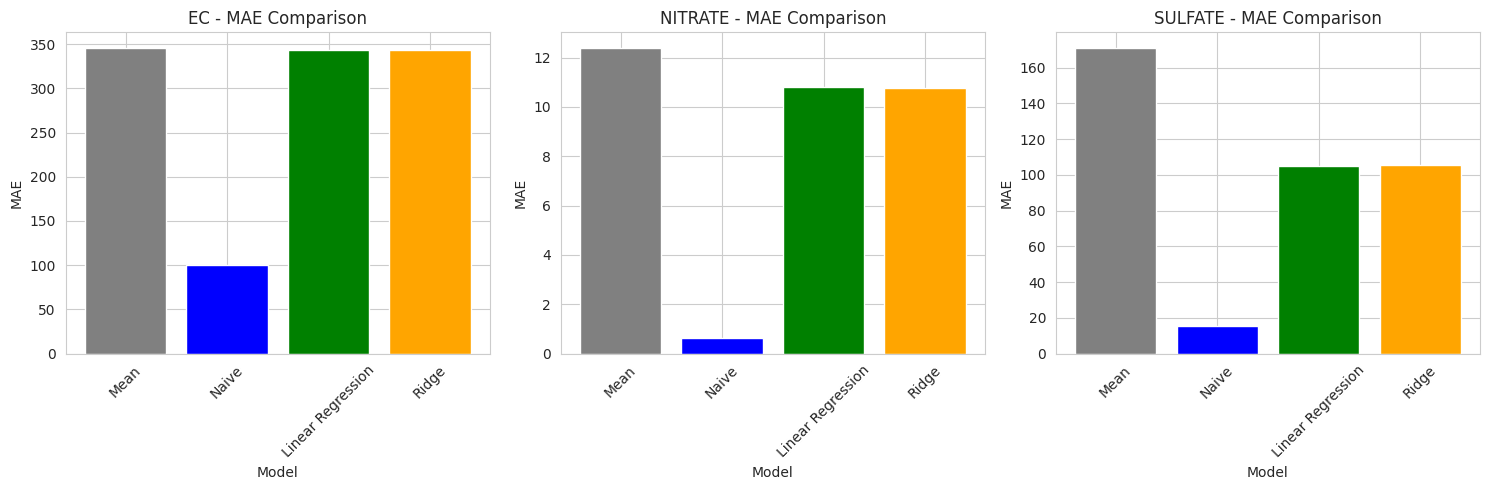

✅ Baseline comparison plot saved to: baseline_comparison.png


In [ ]:
print("=" * 60)
print("📊 COMPARING ALL BASELINE MODELS")
print("=" * 60)

# Combine all results
all_results = pd.concat([
    mean_results_df,
    naive_results_df,
    lr_results_df,
    ridge_results_df
], ignore_index=True)

# Pivot table for comparison
comparison_pivot = all_results.pivot_table(
    index='target',
    columns='model',
    values='MAE'
)

print("\n📌 MAE Comparison (lower is better):")
print(comparison_pivot)

# Save comparison
comparison_pivot.to_excel('baseline_comparison.xlsx')
print("\n✅ Baseline comparison saved to: baseline_comparison.xlsx")

# Create bar plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, target in enumerate(['EC', 'nitrate', 'sulfate']):
    target_data = all_results[all_results['target'] == target]
    models = target_data['model'].values
    mae_values = target_data['MAE'].values

    axes[i].bar(models, mae_values, color=['gray', 'blue', 'green', 'orange'])
    axes[i].set_title(f'{target.upper()} - MAE Comparison')
    axes[i].set_ylabel('MAE')
    axes[i].set_xlabel('Model')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('baseline_comparison.png', dpi=300)
plt.show()
print("✅ Baseline comparison plot saved to: baseline_comparison.png")

In [ ]:
print("=" * 60)
print("📄 GENERATING BASELINE MODELS REPORT")
print("=" * 60)

with open('Baseline_Models_Report.txt', 'w') as f:
    f.write("=" * 80 + "\n")
    f.write("BASELINE MODELS REPORT\n")
    f.write("Groundwater Quality Forecasting Project\n")
    f.write(f"Generated on: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("=" * 80 + "\n\n")

    f.write("1. BASELINE MODELS EVALUATED\n")
    f.write("-" * 40 + "\n")
    f.write("1. Mean Prediction - Predicts the average value from training data\n")
    f.write("2. Naive Prediction - Predicts the last observed value for each station\n")
    f.write("3. Linear Regression - Simple linear relationship\n")
    f.write("4. Ridge Regression - Linear with regularization\n\n")

    f.write("2. COMPARISON RESULTS (MAE - Lower is Better)\n")
    f.write("-" * 40 + "\n")
    f.write(comparison_pivot.to_string())
    f.write("\n\n")

    f.write("3. KEY FINDINGS\n")
    f.write("-" * 40 + "\n")

    # Identify best model for each target
    for target in target_columns:
        target_data = all_results[all_results['target'] == target]
        if len(target_data) > 0:
            best_idx = target_data['MAE'].idxmin()
            best_model = target_data.loc[best_idx, 'model']
            best_mae = target_data.loc[best_idx, 'MAE']
            f.write(f"• {target.upper()}: Best model = {best_model} (MAE = {best_mae:.2f})\n")

    f.write("\n4. OBSERVATIONS\n")
    f.write("-" * 40 + "\n")
    f.write("• Mean prediction is often the simplest baseline\n")
    f.write("• Naive prediction tests if there is temporal structure\n")
    f.write("• Linear Regression tests if relationships are linear\n")
    f.write("• Ridge Regression tests if regularization improves performance\n")
    f.write("• These baselines establish the minimum performance expected from ML models\n")
    f.write("• ML models must outperform these baselines to be considered useful\n\n")

    f.write("5. NEXT STEPS\n")
    f.write("-" * 40 + "\n")
    f.write("• Proceed to Phase 6: Regime Detection (Clustering)\n")
    f.write("• Proceed to Phase 7: Global ML Models (Random Forest, XGBoost)\n")
    f.write("• Compare ML performance against these baselines\n")

print("\n✅ Baseline_Models_Report.txt saved!")

📄 GENERATING BASELINE MODELS REPORT

✅ Baseline_Models_Report.txt saved!


In [ ]:
print("\n" + "=" * 60)
print("📁 FILES GENERATED")
print("=" * 60)

print("""
📊 Excel Files:
  ✅ baseline_mean_results.xlsx
  ✅ baseline_naive_results.xlsx
  ✅ baseline_linear_results.xlsx
  ✅ baseline_ridge_results.xlsx
  ✅ baseline_comparison.xlsx

📈 Plots (PNG):
  ✅ baseline_comparison.png

📄 Text Reports:
  ✅ Baseline_Models_Report.txt

📌 All files are in your current directory.

PHASE 5 COMPLETE! ✅
Baseline Models are ready.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Baseline_Models_Report.txt
  3. Tell me you're ready for Phase 6: Regime Detection (Clustering)
""")


📁 FILES GENERATED

📊 Excel Files:
  ✅ baseline_mean_results.xlsx
  ✅ baseline_naive_results.xlsx
  ✅ baseline_linear_results.xlsx
  ✅ baseline_ridge_results.xlsx
  ✅ baseline_comparison.xlsx

📈 Plots (PNG):
  ✅ baseline_comparison.png

📄 Text Reports:
  ✅ Baseline_Models_Report.txt

📌 All files are in your current directory.

PHASE 5 COMPLETE! ✅
Baseline Models are ready.

NEXT STEPS:
  1. Download all files (click folder icon → right-click → Download)
  2. Review Baseline_Models_Report.txt
  3. Tell me you're ready for Phase 6: Regime Detection (Clustering)

